In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Load Data

In [2]:
berita = pd.read_csv('../data/raw/cnbc_with_published.csv')
berita

,keyword_matched,title,url,preview_summary,full_text,date_raw,section,published_raw,published_date,published_time,published_timezone,published_iso,scrape_status
0,geopolitical risk,Global shipping authorities warn of maritime t...,https://www.cnbc.com/2026/09/08/global-shippin...,Global maritime authorities have warned that t...,Global maritime authorities have warned that t...,9/8/2026 2:28:41 PM,Markets,2026-09-08T07:28:41+0000,2026-09-08,07:28 AM,0.0,2026-09-08T07:28:41+0000,ok
1,geopolitical risk,Morning Call Sheet: AI rebound meets risinggeo...,https://www.cnbc.com/video/2026/07/31/morning-...,"Peter Tchir, Head of Macro Strategy at Academy...",NaN,7/31/2026 5:58:53 PM,Morning Call,NaN,NaN,NaN,NaN,NaN,not_found
2,geopolitical risk,Global markets keep shrugging off shocks. Here...,https://www.cnbc.com/2026/09/08/global-markets...,Global markets have shrugged off a barrage of ...,In this article Global markets have shrugged o...,9/8/2026 11:02:43 AM,World Markets,2026-09-08T04:02:43+0000,2026-09-08,04:02 AM,0.0,2026-09-08T04:02:43+0000,ok
3,geopolitical risk,"Yen hovers near seven-month high, dollar steadies",https://www.cnbc.com/2026/09/08/yen-extends-ra...,The Japanese yen hovered near ​a seven-month h...,In this article The Japanese yen hovered near ...,9/8/2026 11:17:07 AM,Currencies,2026-09-08T04:17:07+0000,2026-09-08,04:17 AM,0.0,2026-09-08T04:17:07+0000,ok
4,geopolitical risk,Central banks are bringing gold reserves home ...,https://www.cnbc.com/2026/06/17/central-banks-...,More and more central banks are storing gold b...,In this article More and more central banks ar...,6/17/2026 2:28:36 PM,Gold,2026-06-17T07:28:36+0000,2026-06-17,07:28 AM,0.0,2026-06-17T07:28:36+0000,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16728,diplomacy,Putin dismisses US hacking allegations as camp...,https://www.cnbc.com/2016/10/16/putin-dismisse...,Russian President Vladimir Putin on Sunday shr...,Russian President Vladimir Putin on Sunday shr...,10/16/2016 9:47:05 PM,Elections,2016-10-16T14:47:05+0000,2016-10-16,02:47 PM,0.0,2016-10-16T14:47:05+0000,ok
16729,diplomacy,US and Britain consider new economic sanctions...,https://www.cnbc.com/2016/10/16/us-and-britain...,"With military options all but eliminated, the ...","With military options all but eliminated, the ...",10/17/2016 12:57:34 AM,US: News,2016-10-16T17:57:34+0000,2016-10-16,05:57 PM,0.0,2016-10-16T17:57:34+0000,ok
16730,diplomacy,Another North Korea intermediate range missile...,https://www.cnbc.com/2016/10/19/failed-north-k...,North Korea fired a missile that failed immedi...,North Koreafired a missile that failed immedia...,10/20/2016 10:40:54 AM,Defense,2016-10-20T03:40:54+0000,2016-10-20,03:40 AM,0.0,2016-10-20T03:40:54+0000,ok
16731,diplomacy,"Iraq is balking at OPEC’s oil output deal, and...",https://www.cnbc.com/2016/10/25/iraq-is-balkin...,Iraq’s insistence that it should be exempt fro...,Iraq's insistence that it should be exempt fro...,10/26/2016 8:13:41 PM,Energy,2016-10-26T13:13:41+0000,2016-10-26,01:13 PM,0.0,2016-10-26T13:13:41+0000,ok


In [3]:
#drop published_date, published_time, published_timezone, scrape_status
berita = berita.drop(columns=['published_date', 'published_time', 'published_timezone', 'scrape_status'])

In [4]:
kurs = pd.read_csv('../data/raw/bi-usd-rate.csv')
kurs

,NO,Nilai,Kurs Jual,Kurs Beli,Tanggal
0,1,1,17834.73,17657.27,9/1/2026 12:00:00 AM
1,2,1,17791.51,17614.49,8/31/2026 12:00:00 AM
2,3,1,17850.81,17673.19,8/28/2026 12:00:00 AM
3,4,1,17805.58,17628.42,8/27/2026 12:00:00 AM
4,5,1,17791.51,17614.49,8/26/2026 12:00:00 AM
...,...,...,...,...,...
1197,1198,1,14310.20,14167.81,9/7/2021 12:00:00 AM
1198,1199,1,14332.31,14189.70,9/6/2021 12:00:00 AM
1199,1200,1,14352.41,14209.60,9/3/2021 12:00:00 AM
1200,1201,1,14355.42,14212.58,9/2/2021 12:00:00 AM


# Preprocess dataset

In [5]:
berita['date_raw'] = pd.to_datetime(berita['date_raw'], format='%m/%d/%Y %I:%M:%S %p')
berita['published_raw'] = pd.to_datetime(berita['published_raw'])
berita['published_iso'] = pd.to_datetime(berita['published_raw'])

In [6]:
berita.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16733 entries, 0 to 16732
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   keyword_matched  16733 non-null  object             
 1   title            16733 non-null  object             
 2   url              16733 non-null  object             
 3   preview_summary  16733 non-null  object             
 4   full_text        13431 non-null  object             
 5   date_raw         16733 non-null  datetime64[ns]     
 6   section          16649 non-null  object             
 7   published_raw    15239 non-null  datetime64[ns, UTC]
 8   published_iso    15239 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](2), datetime64[ns](1), object(6)
memory usage: 1.1+ MB


# Cleaning

In [7]:
berita.duplicated(subset=['title'], keep=False).sum()

#remove duplicate title, keep the first one
berita = berita.drop_duplicates(subset=['title'], keep='first')
berita.shape

(13900, 9)

In [8]:
#filter berita supaya dalam rentang 1 Sept 2021 - 1 Sept 2026
berita = berita[(berita['date_raw'] >= '2021-09-01 00:00:00') & (berita['date_raw'] <= '2026-09-01 23:59:59')]
berita.shape

(7047, 9)

In [9]:
#filter berita yang bukan video (urlnya mengandung kata 'video')
berita = berita[~berita['url'].str.contains('video')]
berita.shape

(6220, 9)

In [10]:
#cek berita yang null di full_text
berita = berita[berita['full_text'].notnull()]
berita.shape

(4887, 9)

In [11]:
berita.isnull().sum()

keyword_matched    0
title              0
url                0
preview_summary    0
full_text          0
date_raw           0
section            1
published_raw      1
published_iso      1
dtype: int64

In [12]:
#fill ke berita yang kosong published_iso dengan date_raw '10/11/2024 12:01:00 AM'
berita.loc[berita['published_iso'].isnull(), 'published_iso'] = pd.to_datetime('2024-10-11T04:01:00+0000')

#fill published_raw yang kosong dengan date_raw '10/11/2024 12:01:00 AM'
berita.loc[berita['published_raw'].isnull(), 'published_raw'] = pd.to_datetime('2024-10-11T04:01:00+0000')

#fill section dengan 'finance'
berita.loc[berita['section'].isnull(), 'section'] = 'finance'

In [13]:
#cek panjang full_text
berita['full_text_length'] = berita['full_text'].apply(len)
berita[['full_text_length']].describe()

,full_text_length
count,4887.000000
mean,4527.992634
std,2616.829462
min,307.000000
25%,2829.500000
50%,4025.000000
75%,5559.000000
max,73759.000000


In [14]:
#drop keyword_match
berita = berita.drop(columns=['keyword_matched'])

In [15]:
#check if full_text_length is less than 350
berita = berita[berita['full_text_length'] > 350]
berita.shape

(4886, 9)

In [16]:
berita

,title,url,preview_summary,full_text,date_raw,section,published_raw,published_iso,full_text_length
4,Central banks are bringing gold reserves home ...,https://www.cnbc.com/2026/06/17/central-banks-...,More and more central banks are storing gold b...,In this article More and more central banks ar...,2026-06-17 14:28:36,Gold,2026-06-17 07:28:36+00:00,2026-06-17 07:28:36+00:00,2949
8,Oil rises 2% as White House says no US-Iran ta...,https://www.cnbc.com/2026/08/27/oil-prices-ext...,"Oil prices rose Thursday, after Washington con...","In this article Oil prices rose Thursday, afte...",2026-08-27 09:49:03,Oil,2026-08-27 02:49:03+00:00,2026-08-27 02:49:03+00:00,3366
9,Jamie Dimon says markets underestimate risks a...,https://www.cnbc.com/2026/07/21/jpmorgan-chase...,JPMorgan Chase CEO Jamie Dimon said investors ...,In this article JPMorgan ChaseCEOJamie Dimonsa...,2026-07-21 06:01:01,Finance,2026-07-20 23:01:01+00:00,2026-07-20 23:01:01+00:00,3183
18,Treasury yields edge higher as investors mapge...,https://www.cnbc.com/2026/07/21/treasury-yield...,U.S. Treasury yields were higher across the cu...,In this article U.S. Treasury yields were high...,2026-07-21 15:25:56,Bonds,2026-07-21 08:25:56+00:00,2026-07-21 08:25:56+00:00,1824
19,China’s super-rich fled Singapore. Now they wa...,https://www.cnbc.com/2026/08/28/chinas-super-r...,"A year ago, wealthy Chinese families were sour...","A year ago, wealthy Chinese familieswere souri...",2026-08-28 06:29:56,Wealth,2026-08-27 23:29:56+00:00,2026-08-27 23:29:56+00:00,6102
...,...,...,...,...,...,...,...,...,...
16229,‘Dark day for Europe’: World leaders condemn R...,https://www.cnbc.com/2022/02/24/leaders-of-us-...,World leaders condemned Russia’s invasion of U...,World leaders condemnedRussia's invasion of Uk...,2022-02-24 16:37:42,World Politics,2022-02-24 09:37:42+00:00,2022-02-24 09:37:42+00:00,5242
16230,Here are the Russian oligarchs targeted in Bid...,https://www.cnbc.com/2022/02/26/here-are-the-r...,"A former KGB leader, a diamond mine executive ...","A former KGB leader, a diamond mine executive ...",2022-02-26 10:13:16,Politics,2022-02-26 03:13:16+00:00,2022-02-26 03:13:16+00:00,5919
16231,Ukraine is ‘not ready to surrender or capitula...,https://www.cnbc.com/2022/02/28/ukraine-not-re...,Ukraine has vowed it will not surrender to Rus...,Ukraine has vowed it will not surrender to Rus...,2022-02-28 21:33:07,Europe Politics,2022-02-28 14:33:07+00:00,2022-02-28 14:33:07+00:00,3411
16232,Huge Russian convoy approaches Kyiv as fears o...,https://www.cnbc.com/2022/03/01/huge-convoy-of...,Russia appears to be advancing in its invasion...,Russia appears to be advancing in its invasion...,2022-03-01 15:09:58,Europe Politics,2022-03-01 08:09:58+00:00,2022-03-01 08:09:58+00:00,7610


In [17]:
berita.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4886 entries, 4 to 16237
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   title             4886 non-null   object             
 1   url               4886 non-null   object             
 2   preview_summary   4886 non-null   object             
 3   full_text         4886 non-null   object             
 4   date_raw          4886 non-null   datetime64[ns]     
 5   section           4886 non-null   object             
 6   published_raw     4886 non-null   datetime64[ns, UTC]
 7   published_iso     4886 non-null   datetime64[ns, UTC]
 8   full_text_length  4886 non-null   int64              
dtypes: datetime64[ns, UTC](2), datetime64[ns](1), int64(1), object(5)
memory usage: 381.7+ KB


# Preprocessing

In [18]:
# change timezone to UTC+7
berita['published_raw'] = berita['published_raw'].dt.tz_convert('Asia/Jakarta')
berita

,title,url,preview_summary,full_text,date_raw,section,published_raw,published_iso,full_text_length
4,Central banks are bringing gold reserves home ...,https://www.cnbc.com/2026/06/17/central-banks-...,More and more central banks are storing gold b...,In this article More and more central banks ar...,2026-06-17 14:28:36,Gold,2026-06-17 14:28:36+07:00,2026-06-17 07:28:36+00:00,2949
8,Oil rises 2% as White House says no US-Iran ta...,https://www.cnbc.com/2026/08/27/oil-prices-ext...,"Oil prices rose Thursday, after Washington con...","In this article Oil prices rose Thursday, afte...",2026-08-27 09:49:03,Oil,2026-08-27 09:49:03+07:00,2026-08-27 02:49:03+00:00,3366
9,Jamie Dimon says markets underestimate risks a...,https://www.cnbc.com/2026/07/21/jpmorgan-chase...,JPMorgan Chase CEO Jamie Dimon said investors ...,In this article JPMorgan ChaseCEOJamie Dimonsa...,2026-07-21 06:01:01,Finance,2026-07-21 06:01:01+07:00,2026-07-20 23:01:01+00:00,3183
18,Treasury yields edge higher as investors mapge...,https://www.cnbc.com/2026/07/21/treasury-yield...,U.S. Treasury yields were higher across the cu...,In this article U.S. Treasury yields were high...,2026-07-21 15:25:56,Bonds,2026-07-21 15:25:56+07:00,2026-07-21 08:25:56+00:00,1824
19,China’s super-rich fled Singapore. Now they wa...,https://www.cnbc.com/2026/08/28/chinas-super-r...,"A year ago, wealthy Chinese families were sour...","A year ago, wealthy Chinese familieswere souri...",2026-08-28 06:29:56,Wealth,2026-08-28 06:29:56+07:00,2026-08-27 23:29:56+00:00,6102
...,...,...,...,...,...,...,...,...,...
16229,‘Dark day for Europe’: World leaders condemn R...,https://www.cnbc.com/2022/02/24/leaders-of-us-...,World leaders condemned Russia’s invasion of U...,World leaders condemnedRussia's invasion of Uk...,2022-02-24 16:37:42,World Politics,2022-02-24 16:37:42+07:00,2022-02-24 09:37:42+00:00,5242
16230,Here are the Russian oligarchs targeted in Bid...,https://www.cnbc.com/2022/02/26/here-are-the-r...,"A former KGB leader, a diamond mine executive ...","A former KGB leader, a diamond mine executive ...",2022-02-26 10:13:16,Politics,2022-02-26 10:13:16+07:00,2022-02-26 03:13:16+00:00,5919
16231,Ukraine is ‘not ready to surrender or capitula...,https://www.cnbc.com/2022/02/28/ukraine-not-re...,Ukraine has vowed it will not surrender to Rus...,Ukraine has vowed it will not surrender to Rus...,2022-02-28 21:33:07,Europe Politics,2022-02-28 21:33:07+07:00,2022-02-28 14:33:07+00:00,3411
16232,Huge Russian convoy approaches Kyiv as fears o...,https://www.cnbc.com/2022/03/01/huge-convoy-of...,Russia appears to be advancing in its invasion...,Russia appears to be advancing in its invasion...,2022-03-01 15:09:58,Europe Politics,2022-03-01 15:09:58+07:00,2022-03-01 08:09:58+00:00,7610


In [19]:
#pisahin tanggal dan waktu
berita['published_date'] = berita['date_raw'].dt.date
berita['published_time'] = berita['date_raw'].dt.time

In [20]:
#pisahin date menjadi year, month, day
berita['published_year'] = berita['date_raw'].dt.year
berita['published_month'] = berita['date_raw'].dt.month
berita['published_day'] = berita['date_raw'].dt.day

#ganti ke int
berita['published_year'] = berita['published_year'].astype(int)
berita['published_month'] = berita['published_month'].astype(int)
berita['published_day'] = berita['published_day'].astype(int)

#pisahin time menjadi hour, minute, second
berita['published_hour'] = berita['date_raw'].dt.hour
berita['published_minute'] = berita['date_raw'].dt.minute
berita['published_second'] = berita['date_raw'].dt.second

In [21]:
berita

,title,url,preview_summary,full_text,date_raw,section,published_raw,published_iso,full_text_length,published_date,published_time,published_year,published_month,published_day,published_hour,published_minute,published_second
4,Central banks are bringing gold reserves home ...,https://www.cnbc.com/2026/06/17/central-banks-...,More and more central banks are storing gold b...,In this article More and more central banks ar...,2026-06-17 14:28:36,Gold,2026-06-17 14:28:36+07:00,2026-06-17 07:28:36+00:00,2949,2026-06-17,14:28:36,2026,6,17,14,28,36
8,Oil rises 2% as White House says no US-Iran ta...,https://www.cnbc.com/2026/08/27/oil-prices-ext...,"Oil prices rose Thursday, after Washington con...","In this article Oil prices rose Thursday, afte...",2026-08-27 09:49:03,Oil,2026-08-27 09:49:03+07:00,2026-08-27 02:49:03+00:00,3366,2026-08-27,09:49:03,2026,8,27,9,49,3
9,Jamie Dimon says markets underestimate risks a...,https://www.cnbc.com/2026/07/21/jpmorgan-chase...,JPMorgan Chase CEO Jamie Dimon said investors ...,In this article JPMorgan ChaseCEOJamie Dimonsa...,2026-07-21 06:01:01,Finance,2026-07-21 06:01:01+07:00,2026-07-20 23:01:01+00:00,3183,2026-07-21,06:01:01,2026,7,21,6,1,1
18,Treasury yields edge higher as investors mapge...,https://www.cnbc.com/2026/07/21/treasury-yield...,U.S. Treasury yields were higher across the cu...,In this article U.S. Treasury yields were high...,2026-07-21 15:25:56,Bonds,2026-07-21 15:25:56+07:00,2026-07-21 08:25:56+00:00,1824,2026-07-21,15:25:56,2026,7,21,15,25,56
19,China’s super-rich fled Singapore. Now they wa...,https://www.cnbc.com/2026/08/28/chinas-super-r...,"A year ago, wealthy Chinese families were sour...","A year ago, wealthy Chinese familieswere souri...",2026-08-28 06:29:56,Wealth,2026-08-28 06:29:56+07:00,2026-08-27 23:29:56+00:00,6102,2026-08-28,06:29:56,2026,8,28,6,29,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16229,‘Dark day for Europe’: World leaders condemn R...,https://www.cnbc.com/2022/02/24/leaders-of-us-...,World leaders condemned Russia’s invasion of U...,World leaders condemnedRussia's invasion of Uk...,2022-02-24 16:37:42,World Politics,2022-02-24 16:37:42+07:00,2022-02-24 09:37:42+00:00,5242,2022-02-24,16:37:42,2022,2,24,16,37,42
16230,Here are the Russian oligarchs targeted in Bid...,https://www.cnbc.com/2022/02/26/here-are-the-r...,"A former KGB leader, a diamond mine executive ...","A former KGB leader, a diamond mine executive ...",2022-02-26 10:13:16,Politics,2022-02-26 10:13:16+07:00,2022-02-26 03:13:16+00:00,5919,2022-02-26,10:13:16,2022,2,26,10,13,16
16231,Ukraine is ‘not ready to surrender or capitula...,https://www.cnbc.com/2022/02/28/ukraine-not-re...,Ukraine has vowed it will not surrender to Rus...,Ukraine has vowed it will not surrender to Rus...,2022-02-28 21:33:07,Europe Politics,2022-02-28 21:33:07+07:00,2022-02-28 14:33:07+00:00,3411,2022-02-28,21:33:07,2022,2,28,21,33,7
16232,Huge Russian convoy approaches Kyiv as fears o...,https://www.cnbc.com/2022/03/01/huge-convoy-of...,Russia appears to be advancing in its invasion...,Russia appears to be advancing in its invasion...,2022-03-01 15:09:58,Europe Politics,2022-03-01 15:09:58+07:00,2022-03-01 08:09:58+00:00,7610,2022-03-01,15:09:58,2022,3,1,15,9,58


# EDA

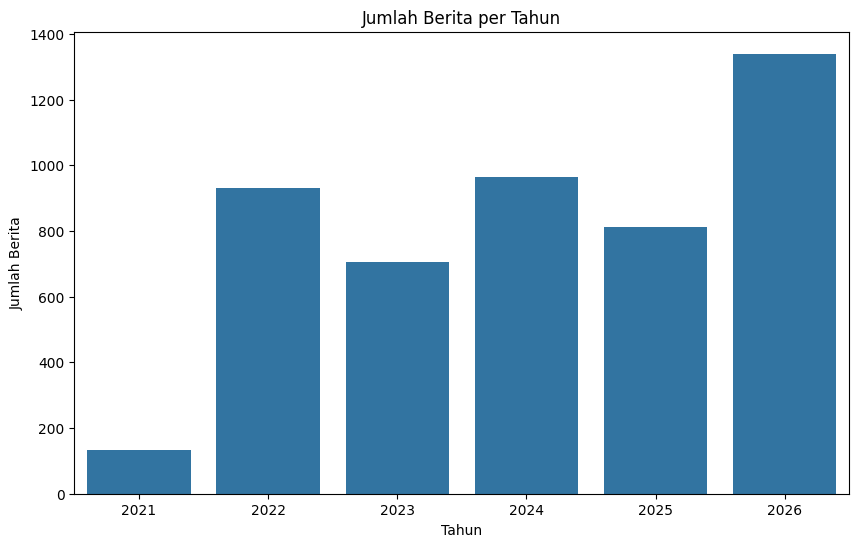

In [22]:
#jumlah berita per tahun
berita_per_tahun = berita.groupby('published_year').size()

#plot jumlah berita per tahun
plt.figure(figsize=(10, 6))
sns.barplot(x=berita_per_tahun.index, y=berita_per_tahun.values)
plt.title('Jumlah Berita per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Berita')
plt.show()

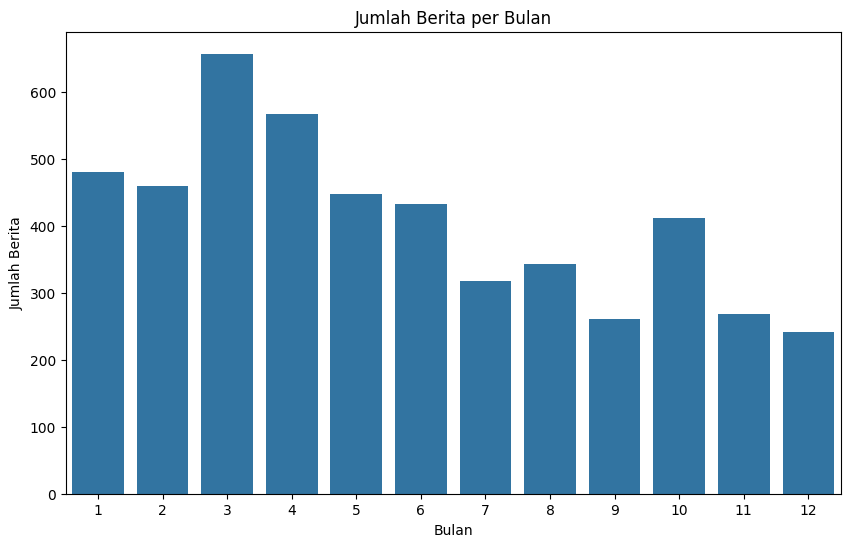

In [23]:
#plot gerak berita per bulan
berita_per_bulan = berita.groupby('published_month').size()

plt.figure(figsize=(10, 6))
sns.barplot(x=berita_per_bulan.index, y=berita_per_bulan.values)
plt.title('Jumlah Berita per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Berita')
plt.show()

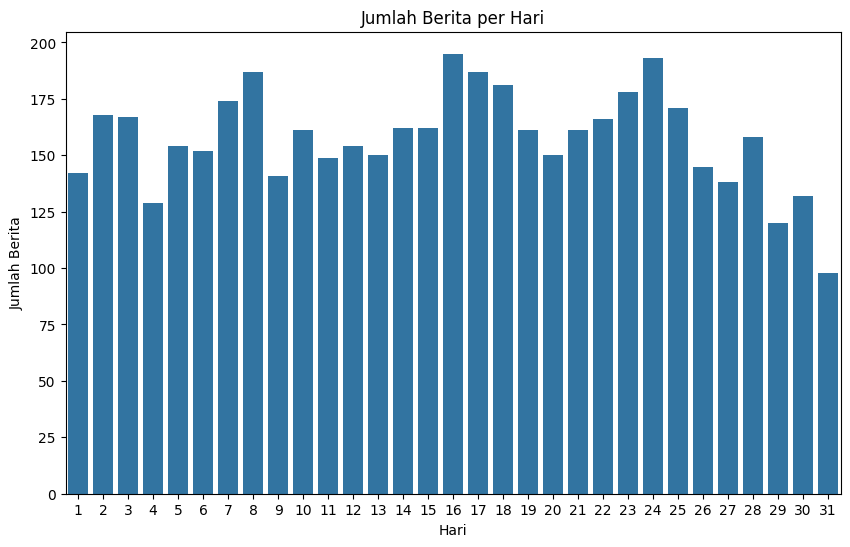

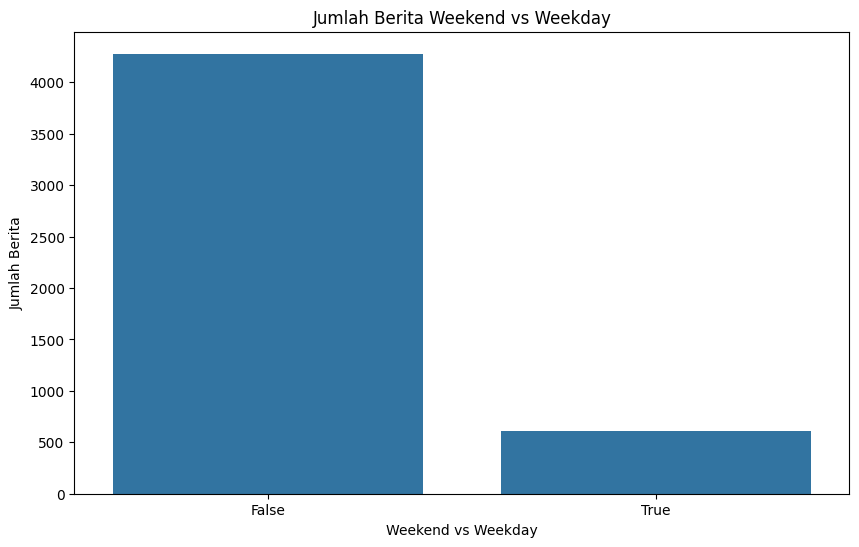

In [24]:
#jumlah berita per hari
berita_per_hari = berita.groupby('published_day').size()

plt.figure(figsize=(10, 6))
sns.barplot(x=berita_per_hari.index, y=berita_per_hari.values)
plt.title('Jumlah Berita per Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Berita')
plt.show()

#plot weekend vs weekday
berita['is_weekend'] = berita['date_raw'].dt.dayofweek >= 5

berita_per_hari = berita.groupby('is_weekend').size()

plt.figure(figsize=(10, 6))
sns.barplot(x=berita_per_hari.index, y=berita_per_hari.values)
plt.title('Jumlah Berita Weekend vs Weekday')
plt.xlabel('Weekend vs Weekday')
plt.ylabel('Jumlah Berita')
plt.show()

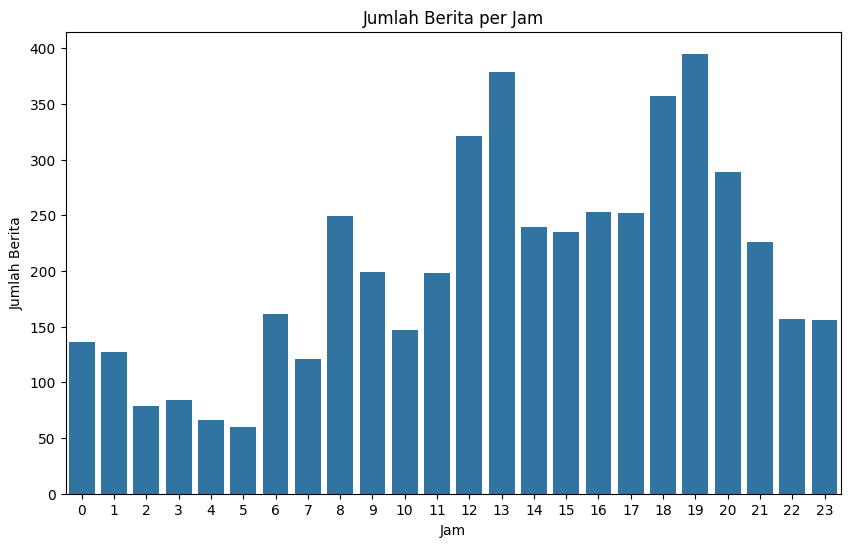

In [25]:
#plot jumlah berita per jam
berita_per_jam = berita.groupby('published_hour').size()

plt.figure(figsize=(10, 6))
sns.barplot(x=berita_per_jam.index, y=berita_per_jam.values)
plt.title('Jumlah Berita per Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Berita')
plt.show()